<a href="https://colab.research.google.com/github/rohithpk12/rohithpk12/blob/main/From_Data_to_Decisions_AQS_EDA_and_Visualization_for_Effective_Air_Quality_Strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import require python classes and packages
import pandas as pd #pandas to read and explore dataset
import numpy as np
import matplotlib.pyplot as plt #use to visualize dataset vallues
import seaborn as sns
import plotly.express as px
import geopandas as gpd #can be use to plot maps
from geopandas import GeoDataFrame
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import svm #SVM class
from sklearn.model_selection import GridSearchCV #grid class for tuning each algorithm
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#loading first dataset
data1 = pd.read_csv("Dataset/epa_air_quality_annual_summary.csv", low_memory=False)
data1

,state_code,county_code,site_num,parameter_code,poc,latitude,longitude,datum,parameter_name,sample_duration,...,seventy_five_percentile,fifty_percentile,ten_percentile,local_site_name,address,state_name,county_name,city_name,cbsa_name,date_of_last_change
0,20,57,1,82134,1,37.771964,-100.018190,WGS84,Molybdenum PM10 STP,24 HOUR,...,0.00000,0.000,0.000,DODGE CITY,PUMP STATION 2100 1ST AVE,Kansas,Ford,Dodge City,Dodge City KS,2012-08-11
1,18,163,12,42401,1,38.021727,-87.569458,WGS84,Sulfur dioxide,3-HR BLK AVG,...,3.60000,1.300,0.000,Evansville CAAP,425 WEST MILL ROAD/ FIRE STATION #17,Indiana,Vanderburgh,Evansville,Evansville IN-KY,2013-02-16
2,40,31,9000,88152,1,34.732404,-98.713351,WGS84,Phosphorus PM2.5 LC,24 HOUR,...,0.00000,0.000,0.000,NaN,Wichita Mountains,Oklahoma,Comanche,NaN,Lawton OK,2016-02-26
3,32,3,561,42601,1,36.163959,-115.113916,WGS84,Nitric oxide (NO),1 HOUR,...,18.80000,0.900,0.000,Sunrise Acres,2501 SUNRISE AVENUE,Nevada,Clark,Las Vegas,Las Vegas-Henderson-Paradise NV,2015-03-20
4,13,127,3001,12154,1,31.185187,-81.485166,WGS84,Selenium (TSP) STP,24 HOUR,...,0.00064,0.000,0.000,NaN,BRUNSWICK COASTAL COLLEGE,Georgia,Glynn,Brunswick,Brunswick GA,2015-07-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2038705,06,13,1002,43802,3,38.006311,-121.641918,WGS84,Dichloromethane,24 HOUR,...,0.00000,0.000,0.000,Bethel Island,5551 BETHEL ISLAND RD,California,Contra Costa,Bethel Island,San Francisco-Oakland-Hayward CA,2012-09-28
2038706,25,25,42,43291,11,42.329500,-71.082600,WGS84,23-Dimethylpentane,24 HOUR,...,0.10000,0.100,0.100,DUDLEY SQUARE ROXBURY,HARRISON AVE,Massachusetts,Suffolk,Boston,Boston-Cambridge-Newton MA-NH,2016-06-22
2038707,06,85,2009,43702,3,37.318435,-122.069705,WGS84,Acetonitrile,24 HOUR,...,0.00000,0.000,0.000,Cupertino Monta Vista,22601 Voss Ave,California,Santa Clara,Cupertino,San Jose-Sunnyvale-Santa Clara CA,2014-04-29
2038708,13,89,2,88374,5,33.687970,-84.290480,WGS84,OC1 CSN_Rev Unadjusted PM2.5 LC,24 HOUR,...,0.30400,0.134,0.036,South DeKalb,2390-B Wildcat Road Decatur GA 30034,Georgia,DeKalb,NaN,Atlanta-Sandy Springs-Roswell GA,2016-03-08


In [ ]:
#loading 2018 dataset as data2
data2 = pd.read_csv("Dataset/annual_conc_by_monitor_2018.csv", low_memory=False)
data2

,state_code,county_code,site_num,parameter_code,poc,latitude,longitude,datum,parameter_name,sample_duration,...,seventy_five_percentile,fifty_percentile,ten_percentile,local_site_name,address,state_name,county_name,city_name,cbsa_name,date_of_last_change
0,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,1 HOUR,...,0.054,0.044,0.030,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-11-03
1,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.049,0.039,0.026,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-11-03
2,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.049,0.039,0.026,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-11-03
3,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.048,0.039,0.026,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-11-03
4,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,8.600,6.600,4.000,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-11-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73426,80,2,24,85101,1,32.654420,-115.407267,NAD83,PM10 - LC,24 HOUR,...,101.000,71.000,42.000,NaN,Calzada Cetys,Country Of Mexico,BAJA CALIFORNIA NORTE,Mexicali,NaN,2020-05-21
73427,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,1 HOUR,...,0.055,0.046,0.036,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2021-11-05
73428,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.048,0.041,0.030,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2021-11-05
73429,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.048,0.041,0.030,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2021-11-05


In [ ]:
#loading 2019 dataset as data3
data3 = pd.read_csv("Dataset/annual_conc_by_monitor_2019.csv", low_memory=False)
data3

,state_code,county_code,site_num,parameter_code,poc,latitude,longitude,datum,parameter_name,sample_duration,...,seventy_five_percentile,fifty_percentile,ten_percentile,local_site_name,address,state_name,county_name,city_name,cbsa_name,date_of_last_change
0,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,1 HOUR,...,0.054,0.045,0.029,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-11-01
1,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.050,0.040,0.026,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-11-01
2,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.050,0.040,0.026,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-11-01
3,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.050,0.040,0.026,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-11-01
4,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,9.500,7.300,3.800,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-11-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68550,80,2,24,85101,1,32.654420,-115.407267,NAD83,PM10 - LC,24 HOUR,...,55.000,38.000,18.000,NaN,Calzada Cetys,Country Of Mexico,BAJA CALIFORNIA NORTE,Mexicali,NaN,2020-05-21
68551,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,1 HOUR,...,0.057,0.051,0.038,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2021-11-03
68552,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.053,0.046,0.032,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2021-11-03
68553,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.053,0.046,0.032,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2021-11-03


In [ ]:
#loading 2020 dataset as data 4
data4 = pd.read_csv("Dataset/annual_conc_by_monitor_2020.csv", low_memory=False)
data4

,state_code,county_code,site_num,parameter_code,poc,latitude,longitude,datum,parameter_name,sample_duration,...,seventy_five_percentile,fifty_percentile,ten_percentile,local_site_name,address,state_name,county_name,city_name,cbsa_name,date_of_last_change
0,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,1 HOUR,...,0.048,0.041,0.025,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-10-30
1,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.044,0.036,0.024,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-10-30
2,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.044,0.036,0.024,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-10-30
3,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.044,0.036,0.024,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-10-30
4,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,10.300,7.400,3.800,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2021-10-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68288,80,2,14,88502,5,32.633671,-115.504995,WGS84,Acceptable PM2.5 AQI & Speciation Mass,24 HOUR,...,0.000,0.000,0.000,"COBACH, CALLE GUADALAJARA JUST SOUTH OF AVENID...","COBACH, COLEGIO DE BACHILLERES, MEXICALI",Country Of Mexico,BAJA CALIFORNIA NORTE,Mexicali,NaN,2021-04-01
68289,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,1 HOUR,...,0.055,0.048,0.039,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2021-11-01
68290,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.050,0.044,0.033,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2021-11-01
68291,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.050,0.044,0.033,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2021-11-01


In [ ]:
#loading 2021 dataset as data5
data5 = pd.read_csv("Dataset/annual_conc_by_monitor_2021.csv", low_memory=False, error_bad_lines=False, encoding='iso-8859-1')
data5

,state_code,county_code,site_num,parameter_code,poc,latitude,longitude,datum,parameter_name,sample_duration,...,seventy_five_percentile,fifty_percentile,ten_percentile,local_site_name,address,state_name,county_name,city_name,cbsa_name,date_of_last_change
0,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,1 HOUR,...,0.049,0.043,0.028,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2022-02-24
1,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.045,0.038,0.025,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2022-02-24
2,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.045,0.038,0.025,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2022-02-24
3,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.045,0.038,0.024,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2022-02-24
4,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,8.800,6.500,4.300,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2022-04-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92815,80,2,14,88502,5,32.633671,-115.504995,WGS84,Acceptable PM2.5 AQI & Speciation Mass,24 HOUR,...,0.000,0.000,0.000,"COBACH, CALLE GUADALAJARA JUST SOUTH OF AVENID...","COBACH, COLEGIO DE BACHILLERES, MEXICALI",Country Of Mexico,BAJA CALIFORNIA NORTE,Mexicali,NaN,2022-04-26
92816,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,1 HOUR,...,0.049,0.043,0.035,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2022-01-14
92817,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.042,0.037,0.030,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2022-01-14
92818,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.042,0.037,0.030,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2022-01-14


In [ ]:
#loading 2022 dataset as data6
data6 = pd.read_csv("Dataset/annual_conc_by_monitor_2022.csv", low_memory=False, error_bad_lines=False, encoding='iso-8859-1')
data6

,state_code,county_code,site_num,parameter_code,poc,latitude,longitude,datum,parameter_name,sample_duration,...,seventy_five_percentile,fifty_percentile,ten_percentile,local_site_name,address,state_name,county_name,city_name,cbsa_name,date_of_last_change
0,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,1 HOUR,...,0.054,0.048,0.030,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2022-09-08
1,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.049,0.044,0.029,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2022-09-08
2,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.049,0.044,0.029,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2022-09-08
3,1,3,10,44201,1,30.497478,-87.880258,NAD83,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.049,0.044,0.029,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2022-09-08
4,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,8.600,7.300,4.000,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2022-10-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51882,80,26,6,88101,1,31.291293,-110.951513,WGS84,PM2.5 - Local Conditions,24-HR BLK AVG,...,10.400,7.800,4.800,Nogales Sonora Institute ITN,"Avenida Instituto Tecnologico #911, Granja, 84...",Country Of Mexico,SONORA,NaN,NaN,2022-10-13
51883,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,1 HOUR,...,0.055,0.048,0.037,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2022-10-14
51884,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.050,0.043,0.033,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2022-10-14
51885,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.050,0.043,0.033,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2022-10-14


In [ ]:
#now merging all datasets from data1 to data6 as single dataset
dataset = pd.concat([data1, data2, data3, data4, data5, data6])
dataset

,state_code,county_code,site_num,parameter_code,poc,latitude,longitude,datum,parameter_name,sample_duration,...,seventy_five_percentile,fifty_percentile,ten_percentile,local_site_name,address,state_name,county_name,city_name,cbsa_name,date_of_last_change
0,20,57,1,82134,1,37.771964,-100.018190,WGS84,Molybdenum PM10 STP,24 HOUR,...,0.00000,0.000,0.000,DODGE CITY,PUMP STATION 2100 1ST AVE,Kansas,Ford,Dodge City,Dodge City KS,2012-08-11
1,18,163,12,42401,1,38.021727,-87.569458,WGS84,Sulfur dioxide,3-HR BLK AVG,...,3.60000,1.300,0.000,Evansville CAAP,425 WEST MILL ROAD/ FIRE STATION #17,Indiana,Vanderburgh,Evansville,Evansville IN-KY,2013-02-16
2,40,31,9000,88152,1,34.732404,-98.713351,WGS84,Phosphorus PM2.5 LC,24 HOUR,...,0.00000,0.000,0.000,NaN,Wichita Mountains,Oklahoma,Comanche,NaN,Lawton OK,2016-02-26
3,32,3,561,42601,1,36.163959,-115.113916,WGS84,Nitric oxide (NO),1 HOUR,...,18.80000,0.900,0.000,Sunrise Acres,2501 SUNRISE AVENUE,Nevada,Clark,Las Vegas,Las Vegas-Henderson-Paradise NV,2015-03-20
4,13,127,3001,12154,1,31.185187,-81.485166,WGS84,Selenium (TSP) STP,24 HOUR,...,0.00064,0.000,0.000,NaN,BRUNSWICK COASTAL COLLEGE,Georgia,Glynn,Brunswick,Brunswick GA,2015-07-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51882,80,26,6,88101,1,31.291293,-110.951513,WGS84,PM2.5 - Local Conditions,24-HR BLK AVG,...,10.40000,7.800,4.800,Nogales Sonora Institute ITN,"Avenida Instituto Tecnologico #911, Granja, 84...",Country Of Mexico,SONORA,NaN,NaN,2022-10-13
51883,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,1 HOUR,...,0.05500,0.048,0.037,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2022-10-14
51884,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.05000,0.043,0.033,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2022-10-14
51885,80,26,8012,44201,1,32.466389,-114.768611,WGS84,Ozone,8-HR RUN AVG BEGIN HOUR,...,0.05000,0.043,0.033,San Luis Rio Colorado Well 10,Calle 15 & Venustiano Carranza Water Well #10,Country Of Mexico,SONORA,NaN,NaN,2022-10-14


In [ ]:
#finding and displaying count of missing or null values
dataset.isnull().sum()

state_code                                0
county_code                               0
site_num                                  0
parameter_code                            0
poc                                       0
latitude                                 10
longitude                                10
datum                                     0
parameter_name                            0
sample_duration                           0
pollutant_standard                  1779852
metric_used                               0
method_name                          270159
year                                      0
units_of_measure                          0
event_type                                0
observation_count                         0
observation_percent                       0
completeness_indicator                    0
valid_day_count                           0
required_day_count                        0
exceptional_data_count                    0
null_data_count                 

In [ ]:
#replacing missing values with 0 and then finding sum of missing values
dataset.fillna(0, inplace = True)
dataset.isnull().sum()

state_code                          0
county_code                         0
site_num                            0
parameter_code                      0
poc                                 0
latitude                            0
longitude                           0
datum                               0
parameter_name                      0
sample_duration                     0
pollutant_standard                  0
metric_used                         0
method_name                         0
year                                0
units_of_measure                    0
event_type                          0
observation_count                   0
observation_percent                 0
completeness_indicator              0
valid_day_count                     0
required_day_count                  0
exceptional_data_count              0
null_data_count                     0
primary_exceedance_count            0
secondary_exceedance_count          0
certification_indicator             0
num_obs_belo

In [ ]:
#detect & remove outliers or anomalies from dataset
low = dataset.quantile(0.25)
high = dataset.quantile(0.75)
IQR = high - low
print("Dataset Size Before Removing Outliers : "+str(dataset.shape[0]))
#remove all anomalies which are failed to satisfy and high and low threshold
dataset = dataset[~((dataset < (low - 1.5 * IQR)) |(dataset > (high + 1.5 * IQR))).any(axis=1)]
print("Dataset Size After Removing Outliers : "+str(dataset.shape[0]))

Dataset Size Before Removing Outliers : 2393696
Dataset Size After Removing Outliers : 892065


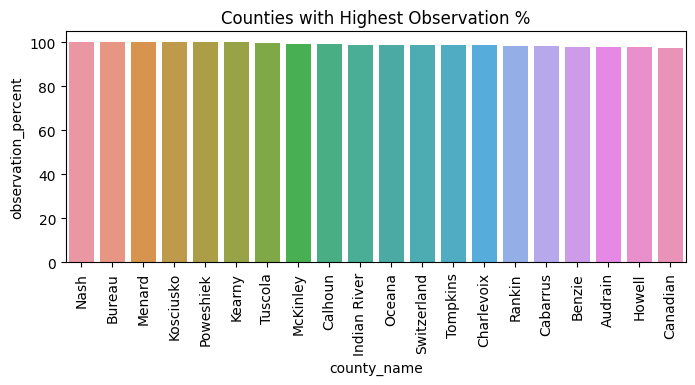

In [ ]:
#using this plot we are finding top 20 county names with highest number of aairr quality observation %
countries_with_highest_measure = (dataset.groupby('county_name')['observation_percent'].mean().sort_values(ascending=False).head(20)).reset_index()
plt.figure(figsize=(8,3))
sns.barplot(x='county_name',y='observation_percent', data=countries_with_highest_measure)
plt.title('Counties with Highest Observation %')
plt.xticks(rotation=90)
plt.show()

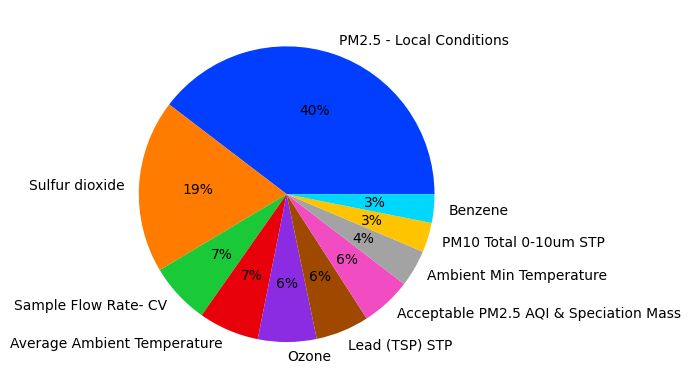

In [ ]:
data = dataset[['city_name', 'parameter_name']]
cities_with_highest_measure = data.groupby(['parameter_name'])['city_name'].count().reset_index()
countries_with_highest_measure = (cities_with_highest_measure.groupby('parameter_name')['city_name'].sum().sort_values(ascending=False).head(10)).reset_index()
palette_color = sns.color_palette('bright')
plt.pie(countries_with_highest_measure['city_name'].ravel(),labels=countries_with_highest_measure['parameter_name'].ravel(),colors=palette_color, autopct='%.0f%%')
plt.show()

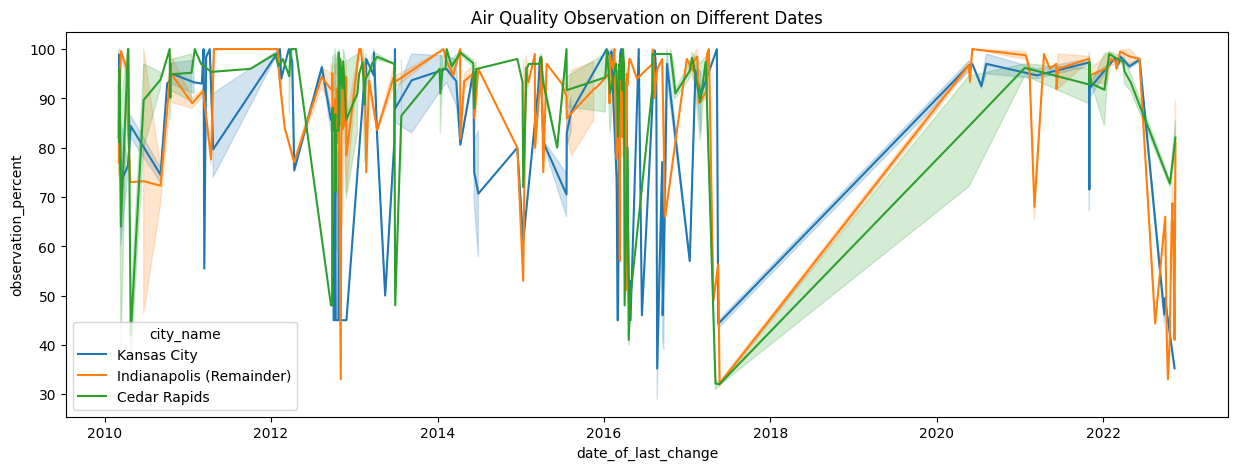

In [ ]:
data = dataset.loc[((dataset['city_name'] == 'Cedar Rapids') | (dataset['city_name'] == 'Kansas City') | (dataset['city_name'] == 'Indianapolis (Remainder)'))]
data["date_of_last_change"] = pd.to_datetime(data["date_of_last_change"])
data.sort_values(by='date_of_last_change', inplace = True)

fig, ax = plt.subplots(figsize=(15, 5))
graph = sns.lineplot(x="date_of_last_change", y="observation_percent", ax=ax, data=data, hue='city_name')
graph.set(title="Air Quality Observation on Different Dates")
plt.show()

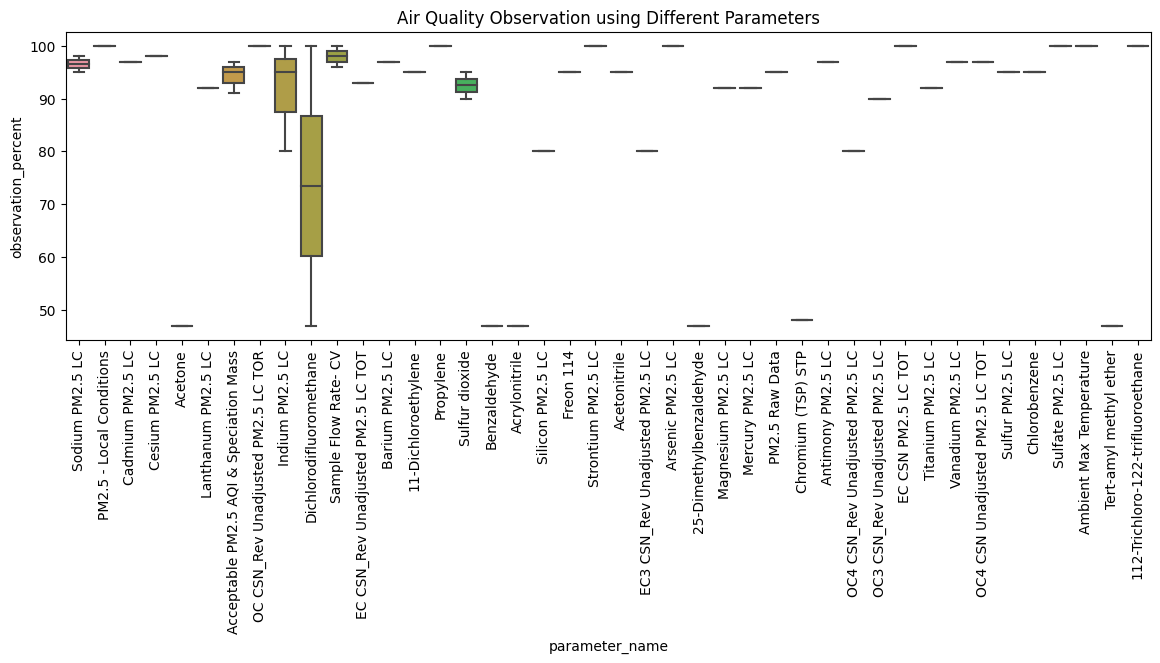

In [ ]:
temp = dataset.loc[((dataset['city_name'] == 'Cedar Rapids'))]
fig, ax = plt.subplots(figsize=(14, 4))
sns.boxplot(data=temp[0:50], x="parameter_name", y="observation_percent")
plt.xticks(rotation=90)
plt.title("Air Quality Observation using Different Parameters")
plt.show()

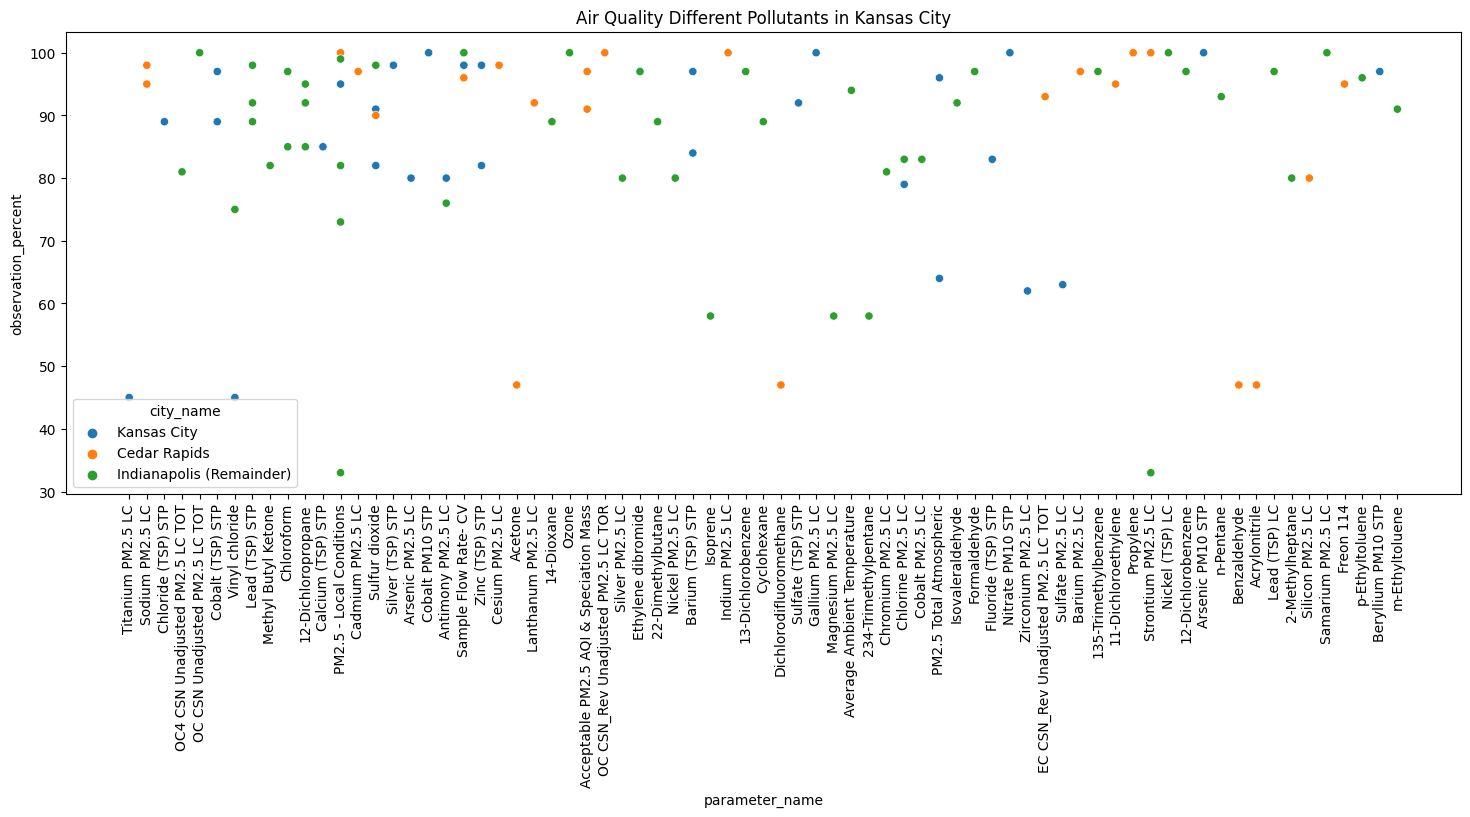

In [ ]:
#data = dataset.loc[((dataset['city_name'] == 'Kansas City'))]
data = dataset.loc[((dataset['city_name'] == 'Cedar Rapids') | (dataset['city_name'] == 'Kansas City') | (dataset['city_name'] == 'Indianapolis (Remainder)'))]
data["date_of_last_change"] = pd.to_datetime(data["date_of_last_change"])
fig, ax = plt.subplots(figsize=(18, 6))
graph = sns.scatterplot(y="observation_percent", x="parameter_name", data=data[0:100], hue="city_name")
graph.set(title="Air Quality Different Pollutants in Kansas City")
plt.xticks(rotation=90)
plt.show()

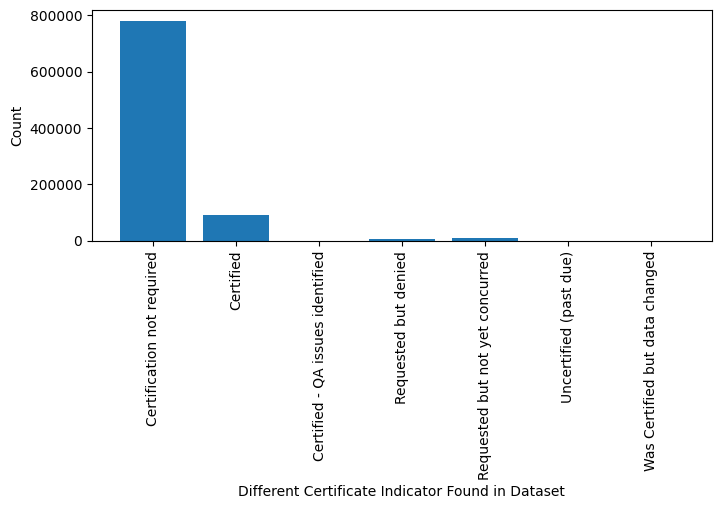

In [ ]:
labels, count = np.unique(dataset['certification_indicator'], return_counts = True)
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (8, 3))
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xticks(rotation=90)
plt.xlabel("Different Certificate Indicator Found in Dataset")
plt.ylabel("Count")
plt.show()

In [ ]:
fig = px.scatter_geo(dataset[0:1000],lat='latitude',lon='longitude', hover_name="city_name")
fig.update_layout(title = 'Stations Located in Different Cities', title_x=0.5)
fig.show()

In [ ]:
import plotly.graph_objects as go
fig = px.scatter_geo(dataset[0:1000],lat='latitude',lon='longitude', hover_name="parameter_name")
fig.update_geos(
    visible=True, resolution=50, scope="north america",
    showcountries=True, countrycolor="Black",
    showsubunits=True, subunitcolor="Blue"
)
fig.update_layout(title='Air Quality Sensing in Differernt Hawaii Location')
fig.show()

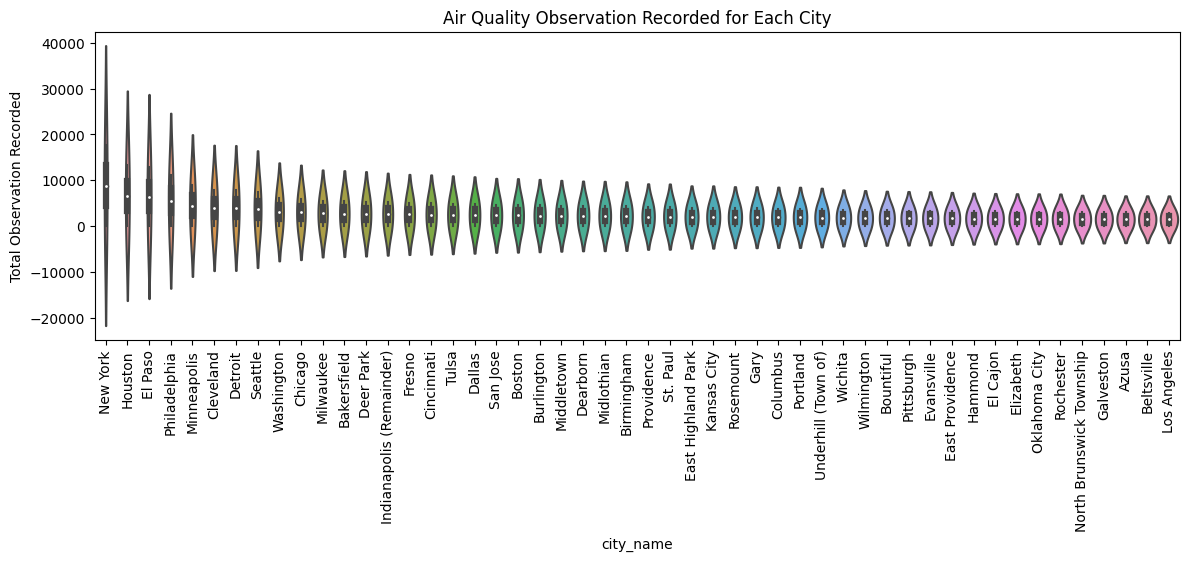

In [ ]:
cities = dataset['city_name'].value_counts().reset_index()
cities = cities.values
values = []
for i in range(len(cities)):
    if cities[i,0] != 0 and cities[i,1] > 150 and cities[i,0] != 'Not in a city':
        values.append([cities[i,0], 0])
        values.append([cities[i,0], cities[i,1]])
cities = pd.DataFrame(values, columns=['city_name', 'Total Observation Recorded'])
fig, ax = plt.subplots(figsize=(14, 4))
sns.violinplot(data=cities[0:100], x="city_name", y="Total Observation Recorded")
plt.xticks(rotation=90)
plt.title("Air Quality Observation Recorded for Each City")
plt.show()

In [ ]:
#dataset cleaning by converting non-numeric data into numeric data
#now convert date column as numeric features by separting them into year, month, day, hour, second and minutes
dataset['date_of_last_change'] = pd.to_datetime(dataset['date_of_last_change'])
dataset['year_value'] = dataset['date_of_last_change'].dt.year
dataset['month'] = dataset['date_of_last_change'].dt.month
dataset['day'] = dataset['date_of_last_change'].dt.day
dataset['hour'] = dataset['date_of_last_change'].dt.hour
dataset['minute'] = dataset['date_of_last_change'].dt.minute
dataset['second'] = dataset['date_of_last_change'].dt.second
dataset.drop(['date_of_last_change'], axis = 1,inplace=True)
#converting non-numeric data to numeric values
label_encoder = []
columns = dataset.columns
types = dataset.dtypes.values
for i in range(len(types)):
    name = types[i]
    if name == 'object': #finding column with object type
        le = LabelEncoder()
        dataset[columns[i]] = pd.Series(le.fit_transform(dataset[columns[i]].astype(str)))#encode all str columns to numeric
        label_encoder.append(le)
dataset.fillna(0, inplace = True)
print("Dataset After Cleaning & Processing")
dataset

Dataset After Cleaning & Processing


,state_code,county_code,site_num,parameter_code,poc,latitude,longitude,datum,parameter_name,sample_duration,...,state_name,county_name,city_name,cbsa_name,year_value,month,day,hour,minute,second
0,15.0,57,1,82134,1,37.771964,-100.018190,1.0,604.0,5.0,...,16.0,332.0,472.0,276.0,2012,8,11,0,0,0
1,13.0,163,12,42401,1,38.021727,-87.569458,1.0,799.0,8.0,...,14.0,936.0,581.0,333.0,2013,2,16,0,0,0
6,34.0,99,2,83152,5,37.648819,-120.997712,1.0,555.0,14.0,...,35.0,956.0,1068.0,623.0,2016,2,26,0,0,0
7,43.0,43,3,88342,1,37.713250,-119.706200,1.0,468.0,0.0,...,43.0,269.0,460.0,247.0,2016,3,1,0,0,0
8,27.0,101,4,45201,2,40.008889,-75.097780,1.0,682.0,5.0,...,28.0,199.0,1259.0,565.0,2015,7,22,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51872,37.0,26,6,44201,1,31.291293,-110.951513,1.0,882.0,5.0,...,37.0,623.0,1406.0,815.0,2022,10,14,0,0,0
51873,25.0,26,6,44201,1,31.291293,-110.951513,1.0,682.0,6.0,...,26.0,328.0,365.0,519.0,2022,10,14,0,0,0
51877,40.0,26,6,88101,1,31.291293,-110.951513,1.0,682.0,6.0,...,40.0,527.0,1589.0,216.0,2022,10,13,0,0,0
51881,9.0,26,6,88101,1,31.291293,-110.951513,1.0,657.0,5.0,...,10.0,593.0,0.0,651.0,2022,10,13,0,0,0


In [ ]:
#Extracting X training features and Y label
Y = dataset['observation_percent'].ravel()
Y = Y.reshape(-1, 1)
dataset.drop(['observation_percent'], axis = 1,inplace=True)
X = dataset.values
#normalizing training features and labels
sc1 = MinMaxScaler(feature_range = (0, 1))
sc2 = MinMaxScaler(feature_range = (0, 1))
X = sc1.fit_transform(X)#normalize train features
Y = sc2.fit_transform(Y)
print("Normalized Features")
print(X)

Normalized Features
[[2.67857143e-01 2.39316239e-01 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [2.32142857e-01 6.92307692e-01 4.58333333e-03 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [6.07142857e-01 4.18803419e-01 4.16666667e-04 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [7.14285714e-01 1.06837607e-01 2.08333333e-03 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.60714286e-01 1.06837607e-01 2.08333333e-03 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [3.57142857e-01 1.06837607e-01 2.08333333e-03 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]


In [ ]:
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2)
print("Total records found in dataset = "+str(X.shape[0]))
print("Total features found in dataset= "+str(X.shape[1]))
print("80% dataset for training : "+str(X_train.shape[0]))
print("20% dataset for testing  : "+str(X_test.shape[0]))

Total records found in dataset = 892065
Total features found in dataset= 59
80% dataset for training : 713652
20% dataset for testing  : 178413


In [ ]:
#define global variables to calculate MSE and RMSE values where MSE and RMSE refers as difference between true traffic
#values and predicted traffic values so the lower the difference the better is the model
mse = []
rmse = []

In [ ]:
#function to calculate MSE and other metrics
def calculateMetrics(algorithm, predict, test_labels):
    mse_value = mean_squared_error(test_labels, predict)
    rmse_value = sqrt(mse_value)
    predict = sc2.inverse_transform(predict)
    test_label = sc2.inverse_transform(test_labels)
    predict = predict.ravel()
    test_label = test_label.ravel()
    predict = predict[0:200]
    test_label = test_label[0:200]
    mse.append(mse_value)
    rmse.append(rmse_value)
    print(algorithm+" MSE  : "+str(mse_value))
    print(algorithm+" RMSE : "+str(rmse_value))
    print()
    for i in range(0, 20):
        print("True Observation Percent : "+str(test_label[i])+" Predicted Observation Percent : "+str(predict[i]))
    plt.figure(figsize=(5,3))
    plt.plot(test_label, color = 'red', label = 'True Air Quality Observation Values')
    plt.plot(predict, color = 'green', label = 'Predicted Air Quality Observation Values')
    plt.title(algorithm+' Air Quality Observation Prediction')
    plt.xlabel('Test Data')
    plt.ylabel('Predicted Air Quality Observation')
    plt.legend()
    plt.show()

Decision Tree MSE  : 0.013370566229902068
Decision Tree RMSE : 0.11563116461361993

True Observation Percent : 87.0 Predicted Observation Percent : 87.90303142104096
True Observation Percent : 86.0 Predicted Observation Percent : 92.36336170210444
True Observation Percent : 39.0 Predicted Observation Percent : 40.123085907086946
True Observation Percent : 64.0 Predicted Observation Percent : 93.19083549870041
True Observation Percent : 97.0 Predicted Observation Percent : 98.36106306929764
True Observation Percent : 60.0 Predicted Observation Percent : 75.27801797425225
True Observation Percent : 98.0 Predicted Observation Percent : 99.22457480626288
True Observation Percent : 48.0 Predicted Observation Percent : 48.11388156317474
True Observation Percent : 80.00000000000001 Predicted Observation Percent : 80.65165257493457
True Observation Percent : 67.0 Predicted Observation Percent : 69.02005325797433
True Observation Percent : 94.0 Predicted Observation Percent : 92.36336170210444


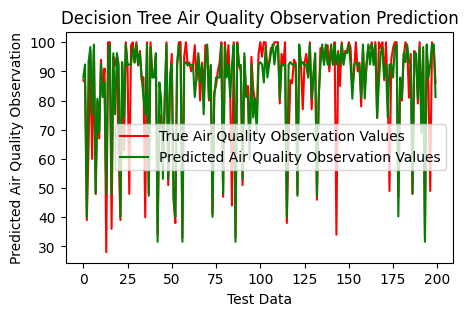

In [ ]:
#train decisoon tree algorithm by tuning its parameters
tuning_param = {'splitter' : ('best', 'random'), 'max_depth' : (2, 5)}
dt_cls = DecisionTreeRegressor() #creasting decision tree object
tuned_dt = GridSearchCV(dt_cls, tuning_param, cv=5)#defining decision tree with tuned parameters
tuned_dt.fit(X_train, y_train.ravel())#now train decision tree
predict = tuned_dt.predict(X_test) #perfrom prediction on test data
predict = predict.reshape(-1, 1)
calculateMetrics("Decision Tree", predict, y_test) #evaluate Decision Tree model by calling caculate metrics function

SVM MSE  : 0.03625252179962906
SVM RMSE : 0.19040095010169739

True Observation Percent : 87.0 Predicted Observation Percent : 87.09950611397561
True Observation Percent : 86.0 Predicted Observation Percent : 108.04838413018479
True Observation Percent : 39.0 Predicted Observation Percent : 67.60729889314408
True Observation Percent : 64.0 Predicted Observation Percent : 86.67281136500415
True Observation Percent : 97.0 Predicted Observation Percent : 87.33693617481676
True Observation Percent : 60.0 Predicted Observation Percent : 88.64321295459474
True Observation Percent : 98.0 Predicted Observation Percent : 89.88850287338781
True Observation Percent : 48.0 Predicted Observation Percent : 57.75043548068794
True Observation Percent : 80.00000000000001 Predicted Observation Percent : 87.09116395149813
True Observation Percent : 67.0 Predicted Observation Percent : 78.91209347991253
True Observation Percent : 94.0 Predicted Observation Percent : 97.00368166246339
True Observation Perc

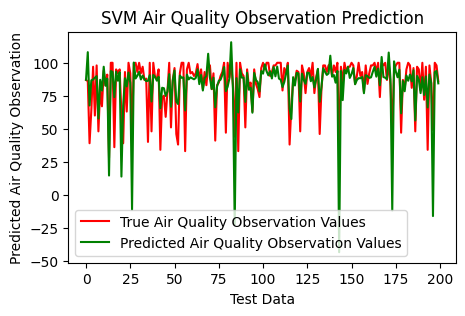

In [ ]:
#train SVM algorithm by tuning its parameters
tuning_param = {'kernel' : ['linear'], 'gamma' : ['auto']}
index = 30000
svm_cls = svm.SVR() #creasting SVM object
tuned_svm = GridSearchCV(svm_cls, tuning_param, cv=5)#defining svm with tuned parameters
tuned_svm.fit(X_train[0:index], y_train.ravel()[0:index])#now train SVM
predict = tuned_svm.predict(X_test[0:10000]) #perfrom prediction on test data
predict = predict.reshape(-1, 1)
calculateMetrics("SVM", predict, y_test[0:10000]) #evaluate SVM model by calling caculate metrics function

Random Forest MSE  : 0.0084425842824074
Random Forest RMSE : 0.09188353651447793

True Observation Percent : 87.0 Predicted Observation Percent : 87.66999999999996
True Observation Percent : 86.0 Predicted Observation Percent : 93.46000000000002
True Observation Percent : 39.0 Predicted Observation Percent : 38.97000000000001
True Observation Percent : 64.0 Predicted Observation Percent : 76.94999999999999
True Observation Percent : 97.0 Predicted Observation Percent : 95.88999999999997
True Observation Percent : 60.0 Predicted Observation Percent : 75.38
True Observation Percent : 98.0 Predicted Observation Percent : 97.9100000000001
True Observation Percent : 48.0 Predicted Observation Percent : 56.160000000000004
True Observation Percent : 80.00000000000001 Predicted Observation Percent : 80.16
True Observation Percent : 67.0 Predicted Observation Percent : 64.15000000000002
True Observation Percent : 94.0 Predicted Observation Percent : 92.4
True Observation Percent : 83.0 Predicte

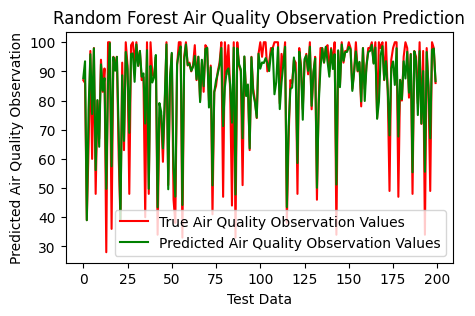

In [ ]:
#train RandomForest algorithm by tuning its parameters
tuning_param = {'n_estimators' : [100], 'max_features' : ['sqrt']}
rf_cls = RandomForestRegressor() #creasting random Forest object
tuned_rf = GridSearchCV(rf_cls, tuning_param, cv=5)#defining RF with tuned parameters
tuned_rf.fit(X_train[0:index], y_train.ravel()[0:index])#now train Random Forest
predict = tuned_rf.predict(X_test[0:10000]) #perfrom prediction on test data
predict = predict.reshape(-1, 1)
calculateMetrics("Random Forest", predict, y_test[0:10000]) #evaluate Random Forest model by calling caculate metrics function

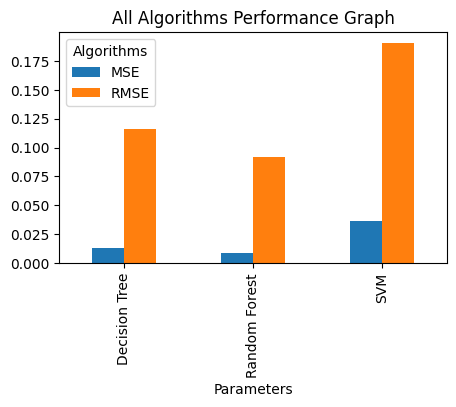

In [ ]:
#plot all algorithm performance
df = pd.DataFrame([
                    ['Decision Tree','MSE',mse[0]],['Decision Tree','RMSE',rmse[0]],
                    ['SVM','MSE',mse[1]],['SVM','RMSE',rmse[1]],
                    ['Random Forest','MSE',mse[2]],['Random Forest','RMSE',rmse[2]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(5,3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [ ]:
#showing all algorithms with scenario A and B performance values
columns = ["Algorithm Name","MSE","RMSE"]
values = []
algorithm_names = ["Decision Tree", "SVM","Random Forest"]
for i in range(len(algorithm_names)):
    values.append([algorithm_names[i],mse[i],rmse[i]])

temp = pd.DataFrame(values,columns=columns)
temp

,Algorithm Name,MSE,RMSE
0,Decision Tree,0.013371,0.115631
1,SVM,0.036253,0.190401
2,Random Forest,0.008443,0.091884


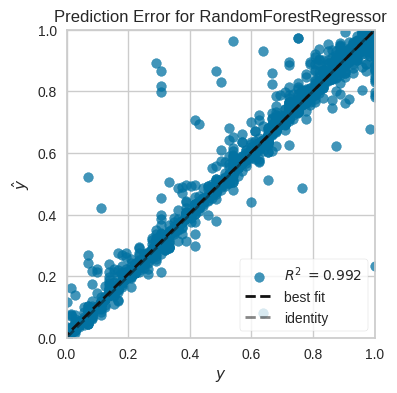

In [ ]:
from yellowbrick.regressor import PredictionError #defining yellow broick class
visualizer = PredictionError(rf_cls)
plt.figure(figsize=(4,4))
visualizer.fit(X_train[0:index], y_train[0:index])  # Fit the training data to the visualizer
visualizer.score(X_test[0:10000], y_test[0:10000])  # Evaluate the model on the test data
g = visualizer.poof()

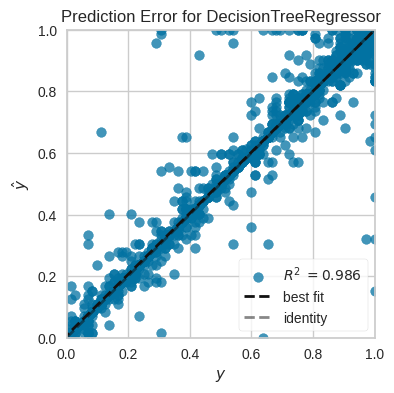

In [ ]:
visualizer = PredictionError(dt_cls)
plt.figure(figsize=(4,4))
visualizer.fit(X_train[0:index], y_train[0:index])  # Fit the training data to the visualizer
visualizer.score(X_test[0:10000], y_test[0:10000])  # Evaluate the model on the test data
g = visualizer.poof()

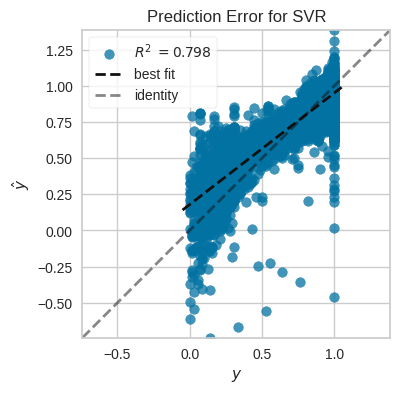

In [ ]:
visualizer = PredictionError(svm_cls)
plt.figure(figsize=(4,4))
visualizer.fit(X_train[0:index], y_train[0:index])  # Fit the training data to the visualizer
visualizer.score(X_test[0:10000], y_test[0:10000])  # Evaluate the model on the test data
g = visualizer.poof()